# Projet Data Science – Analyse des Ventes d'un Café
**Jeu de données : dirty_cafe_sales.csv**

## Partie 1 : Importation des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Partie 2 : Lecture du fichier CSV

In [2]:
df = pd.read_csv("dirty_cafe_sales.csv")

## Partie 3 : Exploration initiale

In [3]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [4]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [5]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [6]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [7]:
df.shape

(10000, 8)

In [8]:
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 1.1 MB


In [10]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


## Partie 4 : Détection et traitement des doublons

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

## Partie 5 : Détection et traitement des valeurs manquantes

In [13]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [14]:
# Remplacer les valeurs corrompues ERROR et UNKNOWN par NaN
import numpy as np
df.replace(["ERROR", "UNKNOWN"], np.nan, inplace=True)
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [15]:
# Conversion des types numeriques
df["Quantity"]       = pd.to_numeric(df["Quantity"],       errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"]    = pd.to_numeric(df["Total Spent"],    errors="coerce")
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
df.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [16]:
# Remplir les colonnes numeriques par la mediane
for col in ["Quantity", "Price Per Unit", "Total Spent"]:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Remplir les colonnes categorielles par le mode
for col in ["Item", "Payment Method", "Location"]:
    df[col] = df[col].fillna(df[col].mode()[0])

# Supprimer les lignes sans date
df.dropna(subset=["Transaction Date"], inplace=True)
df.reset_index(drop=True, inplace=True)

df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [17]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9535,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,2023-08-30
9536,TXN_9659401,Juice,3.0,3.0,3.0,Digital Wallet,Takeaway,2023-06-02
9537,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-03-02
9538,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,Takeaway,2023-12-02


## Partie 6 : Renommer les colonnes

In [18]:
df.rename(columns={
    "Transaction ID"   : "ID_Transaction",
    "Item"             : "Produit",
    "Quantity"         : "Quantite",
    "Price Per Unit"   : "Prix_Unitaire",
    "Total Spent"      : "Total_Depense",
    "Payment Method"   : "Mode_Paiement",
    "Location"         : "Lieu",
    "Transaction Date" : "Date"
}, inplace=True)

df.columns

Index(['ID_Transaction', 'Produit', 'Quantite', 'Prix_Unitaire',
       'Total_Depense', 'Mode_Paiement', 'Lieu', 'Date'],
      dtype='str')

## Partie 7 : Gestion des dates

In [19]:
# Extraction des composantes temporelles
df["Annee"]        = df["Date"].dt.year
df["Mois"]         = df["Date"].dt.month
df["Jour"]         = df["Date"].dt.day
df["Jour_Semaine"] = df["Date"].dt.dayofweek
df["Nom_Jour"]     = df["Date"].dt.day_name()

df[["Date", "Annee", "Mois", "Jour", "Nom_Jour"]]

,Date,Annee,Mois,Jour,Nom_Jour
0,2023-09-08,2023,9,8,Friday
1,2023-05-16,2023,5,16,Tuesday
2,2023-07-19,2023,7,19,Wednesday
3,2023-04-27,2023,4,27,Thursday
4,2023-06-11,2023,6,11,Sunday
...,...,...,...,...,...
9535,2023-08-30,2023,8,30,Wednesday
9536,2023-06-02,2023,6,2,Friday
9537,2023-03-02,2023,3,2,Thursday
9538,2023-12-02,2023,12,2,Saturday


In [20]:
# Tri des donnees par date
df.sort_values(by="Date", inplace=True)
df.reset_index(drop=True, inplace=True)
df

,ID_Transaction,Produit,Quantite,Prix_Unitaire,Total_Depense,Mode_Paiement,Lieu,Date,Annee,Mois,Jour,Jour_Semaine,Nom_Jour
0,TXN_4801947,Juice,1.0,3.0,3.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday
1,TXN_9161256,Smoothie,2.0,4.0,8.0,Digital Wallet,In-store,2023-01-01,2023,1,1,6,Sunday
2,TXN_6093955,Tea,5.0,1.5,8.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday
3,TXN_8842223,Sandwich,5.0,3.0,20.0,Digital Wallet,In-store,2023-01-01,2023,1,1,6,Sunday
4,TXN_7367474,Juice,5.0,3.0,15.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9535,TXN_2806515,Smoothie,4.0,4.0,8.0,Digital Wallet,In-store,2023-12-31,2023,12,31,6,Sunday
9536,TXN_7326974,Cake,4.0,3.0,12.0,Credit Card,Takeaway,2023-12-31,2023,12,31,6,Sunday
9537,TXN_9469735,Cake,1.0,3.0,3.0,Digital Wallet,In-store,2023-12-31,2023,12,31,6,Sunday
9538,TXN_1389258,Salad,1.0,5.0,5.0,Cash,Takeaway,2023-12-31,2023,12,31,6,Sunday


## Partie 8 : Ajout de nouvelles colonnes calculees

In [21]:
# Chiffre d affaires apres remise (hypothese : Total_Depense = prix final paye)
df["CA"] = df["Total_Depense"]
df

,ID_Transaction,Produit,Quantite,Prix_Unitaire,Total_Depense,Mode_Paiement,Lieu,Date,Annee,Mois,Jour,Jour_Semaine,Nom_Jour,CA
0,TXN_4801947,Juice,1.0,3.0,3.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,3.0
1,TXN_9161256,Smoothie,2.0,4.0,8.0,Digital Wallet,In-store,2023-01-01,2023,1,1,6,Sunday,8.0
2,TXN_6093955,Tea,5.0,1.5,8.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,8.0
3,TXN_8842223,Sandwich,5.0,3.0,20.0,Digital Wallet,In-store,2023-01-01,2023,1,1,6,Sunday,20.0
4,TXN_7367474,Juice,5.0,3.0,15.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9535,TXN_2806515,Smoothie,4.0,4.0,8.0,Digital Wallet,In-store,2023-12-31,2023,12,31,6,Sunday,8.0
9536,TXN_7326974,Cake,4.0,3.0,12.0,Credit Card,Takeaway,2023-12-31,2023,12,31,6,Sunday,12.0
9537,TXN_9469735,Cake,1.0,3.0,3.0,Digital Wallet,In-store,2023-12-31,2023,12,31,6,Sunday,3.0
9538,TXN_1389258,Salad,1.0,5.0,5.0,Cash,Takeaway,2023-12-31,2023,12,31,6,Sunday,5.0


## Partie 9 : Filtrage avec conditions

In [22]:
# Transactions avec plus de 3 articles
df[df["Quantite"] > 3]

,ID_Transaction,Produit,Quantite,Prix_Unitaire,Total_Depense,Mode_Paiement,Lieu,Date,Annee,Mois,Jour,Jour_Semaine,Nom_Jour,CA
2,TXN_6093955,Tea,5.0,1.5,8.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,8.0
3,TXN_8842223,Sandwich,5.0,3.0,20.0,Digital Wallet,In-store,2023-01-01,2023,1,1,6,Sunday,20.0
4,TXN_7367474,Juice,5.0,3.0,15.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,15.0
5,TXN_2690222,Juice,4.0,3.0,12.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,12.0
7,TXN_2192787,Sandwich,5.0,4.0,20.0,Cash,In-store,2023-01-01,2023,1,1,6,Sunday,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,TXN_1654784,Cookie,5.0,1.0,5.0,Digital Wallet,In-store,2023-12-31,2023,12,31,6,Sunday,5.0
9530,TXN_9027002,Smoothie,4.0,3.0,16.0,Credit Card,Takeaway,2023-12-31,2023,12,31,6,Sunday,16.0
9532,TXN_2975443,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-12-31,2023,12,31,6,Sunday,25.0
9535,TXN_2806515,Smoothie,4.0,4.0,8.0,Digital Wallet,In-store,2023-12-31,2023,12,31,6,Sunday,8.0


In [23]:
# Transactions avec montant superieur a 15
df[df["Total_Depense"] > 15]

,ID_Transaction,Produit,Quantite,Prix_Unitaire,Total_Depense,Mode_Paiement,Lieu,Date,Annee,Mois,Jour,Jour_Semaine,Nom_Jour,CA
3,TXN_8842223,Sandwich,5.0,3.0,20.0,Digital Wallet,In-store,2023-01-01,2023,1,1,6,Sunday,20.0
7,TXN_2192787,Sandwich,5.0,4.0,20.0,Cash,In-store,2023-01-01,2023,1,1,6,Sunday,20.0
25,TXN_2714524,Sandwich,4.0,4.0,16.0,Cash,Takeaway,2023-01-02,2023,1,2,0,Monday,16.0
28,TXN_5741619,Smoothie,3.0,4.0,20.0,Cash,Takeaway,2023-01-02,2023,1,2,0,Monday,20.0
34,TXN_7906197,Sandwich,5.0,4.0,20.0,Credit Card,In-store,2023-01-02,2023,1,2,0,Monday,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9501,TXN_4375698,Sandwich,3.0,4.0,20.0,Credit Card,In-store,2023-12-30,2023,12,30,5,Saturday,20.0
9520,TXN_5949517,Juice,5.0,4.0,20.0,Digital Wallet,In-store,2023-12-31,2023,12,31,6,Sunday,20.0
9523,TXN_2064365,Sandwich,5.0,4.0,20.0,Digital Wallet,In-store,2023-12-31,2023,12,31,6,Sunday,20.0
9530,TXN_9027002,Smoothie,4.0,3.0,16.0,Credit Card,Takeaway,2023-12-31,2023,12,31,6,Sunday,16.0


In [24]:
# Conditions multiples : Coffee paye en Digital Wallet
df[(df["Produit"] == "Coffee") & (df["Mode_Paiement"] == "Digital Wallet")]

,ID_Transaction,Produit,Quantite,Prix_Unitaire,Total_Depense,Mode_Paiement,Lieu,Date,Annee,Mois,Jour,Jour_Semaine,Nom_Jour,CA
12,TXN_3093284,Coffee,4.0,2.0,8.0,Digital Wallet,In-store,2023-01-01,2023,1,1,6,Sunday,8.0
13,TXN_5358805,Coffee,5.0,2.0,10.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,10.0
14,TXN_1604072,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,4.0
31,TXN_6935600,Coffee,3.0,2.0,6.0,Digital Wallet,Takeaway,2023-01-02,2023,1,2,0,Monday,6.0
44,TXN_7686476,Coffee,3.0,2.0,6.0,Digital Wallet,Takeaway,2023-01-03,2023,1,3,1,Tuesday,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9424,TXN_4334932,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-12-27,2023,12,27,2,Wednesday,4.0
9430,TXN_8640655,Coffee,3.0,2.0,6.0,Digital Wallet,Takeaway,2023-12-27,2023,12,27,2,Wednesday,6.0
9441,TXN_3484190,Coffee,5.0,2.0,10.0,Digital Wallet,Takeaway,2023-12-27,2023,12,27,2,Wednesday,10.0
9494,TXN_6994245,Coffee,4.0,2.0,8.0,Digital Wallet,In-store,2023-12-30,2023,12,30,5,Saturday,8.0


In [25]:
# Condition OU : Coffee ou Tea
df[(df["Produit"] == "Coffee") | (df["Produit"] == "Tea")]

,ID_Transaction,Produit,Quantite,Prix_Unitaire,Total_Depense,Mode_Paiement,Lieu,Date,Annee,Mois,Jour,Jour_Semaine,Nom_Jour,CA
2,TXN_6093955,Tea,5.0,1.5,8.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,8.0
8,TXN_5563675,Tea,3.0,1.5,4.5,Digital Wallet,In-store,2023-01-01,2023,1,1,6,Sunday,4.5
12,TXN_3093284,Coffee,4.0,2.0,8.0,Digital Wallet,In-store,2023-01-01,2023,1,1,6,Sunday,8.0
13,TXN_5358805,Coffee,5.0,2.0,10.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,10.0
14,TXN_1604072,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9516,TXN_2845506,Tea,2.0,1.5,3.0,Digital Wallet,Takeaway,2023-12-30,2023,12,30,5,Saturday,3.0
9518,TXN_2699745,Coffee,4.0,2.0,8.0,Digital Wallet,In-store,2023-12-30,2023,12,30,5,Saturday,8.0
9524,TXN_7108012,Tea,1.0,1.5,1.5,Digital Wallet,Takeaway,2023-12-31,2023,12,31,6,Sunday,1.5
9526,TXN_9738758,Coffee,1.0,2.0,8.0,Cash,In-store,2023-12-31,2023,12,31,6,Sunday,8.0


In [26]:
# Filtrer avec isin
df[df["Lieu"].isin(["In-store", "Takeaway"])]

,ID_Transaction,Produit,Quantite,Prix_Unitaire,Total_Depense,Mode_Paiement,Lieu,Date,Annee,Mois,Jour,Jour_Semaine,Nom_Jour,CA
0,TXN_4801947,Juice,1.0,3.0,3.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,3.0
1,TXN_9161256,Smoothie,2.0,4.0,8.0,Digital Wallet,In-store,2023-01-01,2023,1,1,6,Sunday,8.0
2,TXN_6093955,Tea,5.0,1.5,8.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,8.0
3,TXN_8842223,Sandwich,5.0,3.0,20.0,Digital Wallet,In-store,2023-01-01,2023,1,1,6,Sunday,20.0
4,TXN_7367474,Juice,5.0,3.0,15.0,Digital Wallet,Takeaway,2023-01-01,2023,1,1,6,Sunday,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9535,TXN_2806515,Smoothie,4.0,4.0,8.0,Digital Wallet,In-store,2023-12-31,2023,12,31,6,Sunday,8.0
9536,TXN_7326974,Cake,4.0,3.0,12.0,Credit Card,Takeaway,2023-12-31,2023,12,31,6,Sunday,12.0
9537,TXN_9469735,Cake,1.0,3.0,3.0,Digital Wallet,In-store,2023-12-31,2023,12,31,6,Sunday,3.0
9538,TXN_1389258,Salad,1.0,5.0,5.0,Cash,Takeaway,2023-12-31,2023,12,31,6,Sunday,5.0


In [27]:
# Filtrer par date (donnees de juillet 2023)
df[df["Date"] > "2023-07-01"]

,ID_Transaction,Produit,Quantite,Prix_Unitaire,Total_Depense,Mode_Paiement,Lieu,Date,Annee,Mois,Jour,Jour_Semaine,Nom_Jour,CA
4760,TXN_5639485,Cookie,3.0,1.0,3.0,Credit Card,Takeaway,2023-07-02,2023,7,2,6,Sunday,3.0
4761,TXN_6972491,Sandwich,1.0,4.0,4.0,Digital Wallet,Takeaway,2023-07-02,2023,7,2,6,Sunday,4.0
4762,TXN_7153455,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-07-02,2023,7,2,6,Sunday,8.0
4763,TXN_3717307,Cookie,3.0,1.0,1.0,Credit Card,In-store,2023-07-02,2023,7,2,6,Sunday,1.0
4764,TXN_6293225,Cake,4.0,3.0,12.0,Cash,Takeaway,2023-07-02,2023,7,2,6,Sunday,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9535,TXN_2806515,Smoothie,4.0,4.0,8.0,Digital Wallet,In-store,2023-12-31,2023,12,31,6,Sunday,8.0
9536,TXN_7326974,Cake,4.0,3.0,12.0,Credit Card,Takeaway,2023-12-31,2023,12,31,6,Sunday,12.0
9537,TXN_9469735,Cake,1.0,3.0,3.0,Digital Wallet,In-store,2023-12-31,2023,12,31,6,Sunday,3.0
9538,TXN_1389258,Salad,1.0,5.0,5.0,Cash,Takeaway,2023-12-31,2023,12,31,6,Sunday,5.0


In [28]:
# Filtrer par mois
df[df["Date"].dt.month == 6]

,ID_Transaction,Produit,Quantite,Prix_Unitaire,Total_Depense,Mode_Paiement,Lieu,Date,Annee,Mois,Jour,Jour_Semaine,Nom_Jour,CA
3923,TXN_9230615,Smoothie,4.0,4.0,16.0,Digital Wallet,Takeaway,2023-06-01,2023,6,1,3,Thursday,16.0
3924,TXN_3620110,Coffee,1.0,2.0,2.0,Digital Wallet,Takeaway,2023-06-01,2023,6,1,3,Thursday,2.0
3925,TXN_3163567,Salad,2.0,5.0,8.0,Digital Wallet,Takeaway,2023-06-01,2023,6,1,3,Thursday,8.0
3926,TXN_5238755,Cookie,3.0,1.0,3.0,Digital Wallet,Takeaway,2023-06-01,2023,6,1,3,Thursday,3.0
3927,TXN_1711730,Juice,5.0,3.0,15.0,Digital Wallet,Takeaway,2023-06-01,2023,6,1,3,Thursday,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4736,TXN_4868913,Cake,4.0,3.0,12.0,Cash,Takeaway,2023-06-30,2023,6,30,4,Friday,12.0
4737,TXN_5808539,Sandwich,1.0,4.0,8.0,Digital Wallet,Takeaway,2023-06-30,2023,6,30,4,Friday,8.0
4738,TXN_8361821,Tea,5.0,1.5,7.5,Cash,In-store,2023-06-30,2023,6,30,4,Friday,7.5
4739,TXN_3745153,Smoothie,4.0,4.0,16.0,Digital Wallet,In-store,2023-06-30,2023,6,30,4,Friday,16.0


## Partie 10 : Tri des données

In [29]:
# Tri par montant croissant
df.sort_values(by="Total_Depense")

,ID_Transaction,Produit,Quantite,Prix_Unitaire,Total_Depense,Mode_Paiement,Lieu,Date,Annee,Mois,Jour,Jour_Semaine,Nom_Jour,CA
6673,TXN_6574910,Cookie,1.0,1.0,1.0,Digital Wallet,Takeaway,2023-09-13,2023,9,13,2,Wednesday,1.0
5745,TXN_4020100,Cookie,1.0,1.0,1.0,Cash,In-store,2023-08-09,2023,8,9,2,Wednesday,1.0
3820,TXN_4696439,Cookie,1.0,1.0,1.0,Cash,In-store,2023-05-27,2023,5,27,5,Saturday,1.0
3837,TXN_1696300,Cookie,1.0,1.0,1.0,Digital Wallet,In-store,2023-05-28,2023,5,28,6,Sunday,1.0
6565,TXN_6034920,Cookie,1.0,1.0,1.0,Credit Card,In-store,2023-09-09,2023,9,9,5,Saturday,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2281,TXN_1183995,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-03-28,2023,3,28,1,Tuesday,25.0
2297,TXN_3985920,Salad,5.0,5.0,25.0,Digital Wallet,In-store,2023-03-29,2023,3,29,2,Wednesday,25.0
5661,TXN_7343660,Salad,5.0,5.0,25.0,Credit Card,In-store,2023-08-06,2023,8,6,6,Sunday,25.0
2229,TXN_6456008,Salad,5.0,5.0,25.0,Credit Card,In-store,2023-03-26,2023,3,26,6,Sunday,25.0


In [30]:
# Tri par montant decroissant
df.sort_values(by="Total_Depense", ascending=False)

,ID_Transaction,Produit,Quantite,Prix_Unitaire,Total_Depense,Mode_Paiement,Lieu,Date,Annee,Mois,Jour,Jour_Semaine,Nom_Jour,CA
7288,TXN_4496616,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-10-07,2023,10,7,5,Saturday,25.0
2184,TXN_4336291,Salad,5.0,5.0,25.0,Cash,In-store,2023-03-25,2023,3,25,5,Saturday,25.0
3602,TXN_9455679,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-05-18,2023,5,18,3,Thursday,25.0
3908,TXN_2006923,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-05-31,2023,5,31,2,Wednesday,25.0
1563,TXN_3113823,Salad,5.0,3.0,25.0,Digital Wallet,In-store,2023-03-01,2023,3,1,2,Wednesday,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4007,TXN_9313535,Cookie,1.0,1.0,1.0,Digital Wallet,Takeaway,2023-06-04,2023,6,4,6,Sunday,1.0
2503,TXN_3038078,Cookie,1.0,1.0,1.0,Credit Card,Takeaway,2023-04-06,2023,4,6,3,Thursday,1.0
5883,TXN_3515730,Juice,1.0,1.0,1.0,Credit Card,Takeaway,2023-08-14,2023,8,14,0,Monday,1.0
1846,TXN_1130142,Cookie,1.0,1.0,1.0,Credit Card,In-store,2023-03-13,2023,3,13,0,Monday,1.0


In [31]:
# Tri par plusieurs colonnes
df.sort_values(by=["Produit", "Total_Depense"])

,ID_Transaction,Produit,Quantite,Prix_Unitaire,Total_Depense,Mode_Paiement,Lieu,Date,Annee,Mois,Jour,Jour_Semaine,Nom_Jour,CA
30,TXN_9649503,Cake,1.0,3.0,3.0,Credit Card,Takeaway,2023-01-02,2023,1,2,0,Monday,3.0
203,TXN_5991995,Cake,1.0,3.0,3.0,Digital Wallet,In-store,2023-01-08,2023,1,8,6,Sunday,3.0
211,TXN_7764304,Cake,3.0,3.0,3.0,Credit Card,Takeaway,2023-01-09,2023,1,9,0,Monday,3.0
278,TXN_3869958,Cake,1.0,3.0,3.0,Digital Wallet,Takeaway,2023-01-11,2023,1,11,2,Wednesday,3.0
301,TXN_7585599,Cake,1.0,3.0,3.0,Credit Card,Takeaway,2023-01-12,2023,1,12,3,Thursday,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8587,TXN_8989148,Tea,2.0,1.5,8.0,Digital Wallet,Takeaway,2023-11-25,2023,11,25,5,Saturday,8.0
8812,TXN_7975336,Tea,5.0,1.5,8.0,Credit Card,Takeaway,2023-12-03,2023,12,3,6,Sunday,8.0
9232,TXN_2153838,Tea,4.0,1.5,8.0,Digital Wallet,In-store,2023-12-19,2023,12,19,1,Tuesday,8.0
9339,TXN_5664982,Tea,5.0,1.5,8.0,Digital Wallet,In-store,2023-12-24,2023,12,24,6,Sunday,8.0


## Partie 11 : value_counts

In [32]:
# Frequence des produits
df["Produit"].value_counts()

Produit
Juice       2051
Coffee      1123
Salad       1099
Cake        1082
Sandwich    1075
Smoothie    1048
Cookie      1035
Tea         1027
Name: count, dtype: int64

In [33]:
# Pourcentage
df["Produit"].value_counts(normalize=True)

Produit
Juice       0.214990
Coffee      0.117715
Salad       0.115199
Cake        0.113417
Sandwich    0.112683
Smoothie    0.109853
Cookie      0.108491
Tea         0.107652
Name: proportion, dtype: float64

In [34]:
df["Mode_Paiement"].value_counts()

Mode_Paiement
Digital Wallet    5212
Credit Card       2170
Cash              2158
Name: count, dtype: int64

In [35]:
df["Lieu"].value_counts()

Lieu
Takeaway    6668
In-store    2872
Name: count, dtype: int64

## Partie 12 : Analyse par groupe (groupby)

In [36]:
# CA total par produit (tri decroissant)
df.groupby("Produit")["Total_Depense"].sum().sort_values(ascending=False)

Produit
Juice       18087.0
Salad       16263.0
Sandwich    12824.0
Smoothie    12576.0
Cake         9777.0
Coffee       6922.0
Tea          4813.5
Cookie       3346.0
Name: Total_Depense, dtype: float64

In [37]:
# Plusieurs statistiques par produit
df.groupby("Produit")["Total_Depense"].agg(["sum", "mean", "max", "min"])

,sum,mean,max,min
Produit,,,,
Cake,9777.0,9.036044,15.0,3.0
Coffee,6922.0,6.163847,10.0,2.0
Cookie,3346.0,3.232850,8.0,1.0
Juice,18087.0,8.818625,25.0,1.0
Salad,16263.0,14.797998,25.0,5.0
Sandwich,12824.0,11.929302,20.0,4.0
Smoothie,12576.0,12.000000,20.0,4.0
Tea,4813.5,4.686952,8.0,1.5


In [38]:
# CA moyen par lieu
df.groupby("Lieu")["Total_Depense"].mean()

Lieu
In-store    8.981198
Takeaway    8.820411
Name: Total_Depense, dtype: float64

In [39]:
# Groupement sur plusieurs colonnes : produit + lieu
df.groupby(["Produit", "Lieu"])["Total_Depense"].sum()

Produit   Lieu    
Cake      In-store     2816.0
          Takeaway     6961.0
Coffee    In-store     1880.0
          Takeaway     5042.0
Cookie    In-store     1044.0
          Takeaway     2302.0
Juice     In-store     5511.5
          Takeaway    12575.5
Salad     In-store     5285.0
          Takeaway    10978.0
Sandwich  In-store     4292.0
          Takeaway     8532.0
Smoothie  In-store     3524.0
          Takeaway     9052.0
Tea       In-store     1441.5
          Takeaway     3372.0
Name: Total_Depense, dtype: float64

In [40]:
# CA par mode de paiement
df.groupby("Mode_Paiement")["Total_Depense"].sum().sort_values(ascending=False)

Mode_Paiement
Digital Wallet    45713.0
Cash              19449.5
Credit Card       19446.0
Name: Total_Depense, dtype: float64

In [41]:
# CA par mois (analyse temporelle)
df.groupby(df["Date"].dt.month)["Total_Depense"].sum()

Date
1     7221.0
2     6584.0
3     7198.0
4     7138.5
5     6970.0
6     7327.5
7     6910.0
8     7112.0
9     6829.5
10    7336.5
11    6884.5
12    7097.0
Name: Total_Depense, dtype: float64

In [42]:
# CA moyen par jour de la semaine
df.groupby("Nom_Jour")["Total_Depense"].mean()

Nom_Jour
Friday       8.835735
Monday       8.799928
Saturday     8.818851
Sunday       8.874275
Thursday     8.958333
Tuesday      9.120519
Wednesday    8.680835
Name: Total_Depense, dtype: float64

## Partie 13 : Visualisations

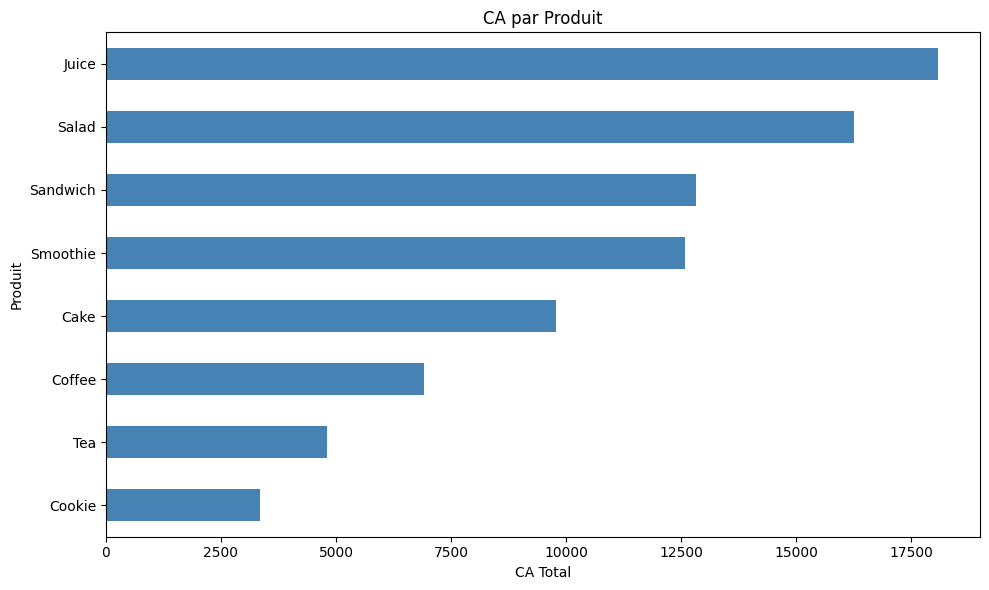

In [43]:
# Graphique 1 : CA par produit (barres)
ca_produit = df.groupby("Produit")["Total_Depense"].sum().sort_values()
ca_produit.plot(kind="barh", color="steelblue", figsize=(10, 6))
plt.title("CA par Produit")
plt.xlabel("CA Total")
plt.tight_layout()
plt.show()

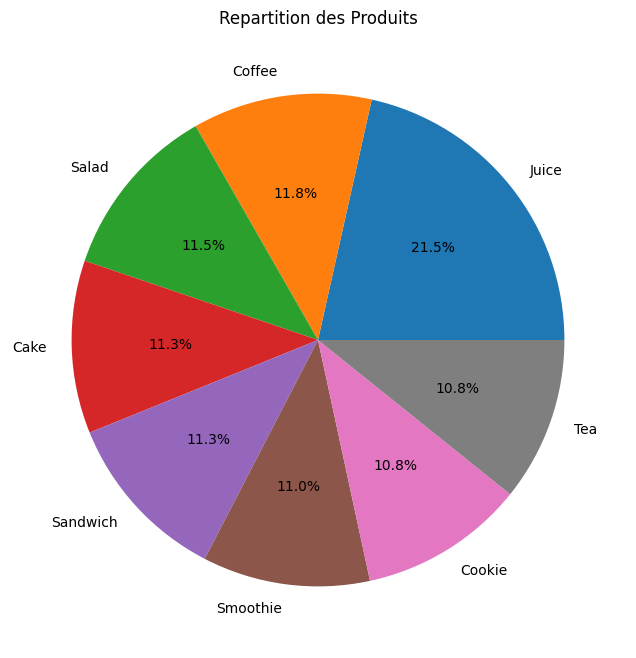

In [44]:
# Graphique 2 : Repartition des produits (camembert)
df["Produit"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(8, 8))
plt.title("Repartition des Produits")
plt.ylabel("")
plt.show()

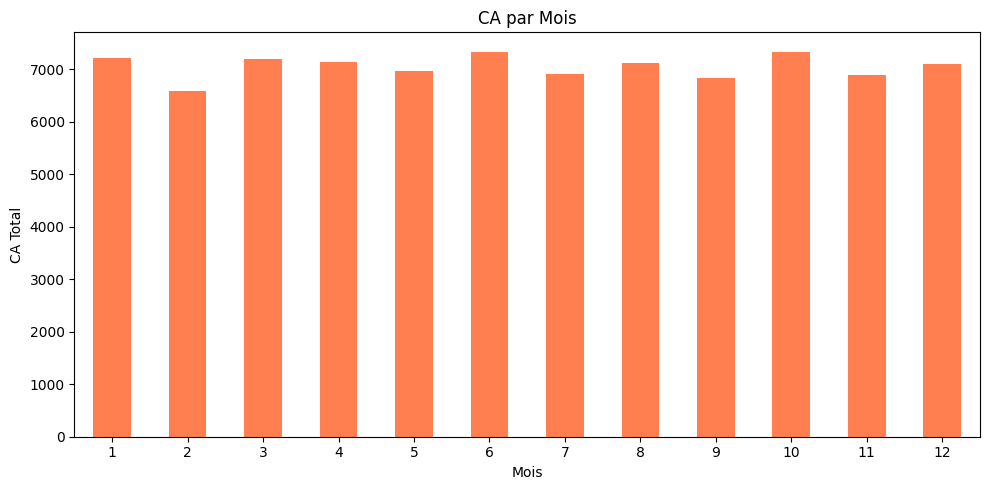

In [45]:
# Graphique 3 : CA mensuel
ca_mensuel = df.groupby(df["Date"].dt.month)["Total_Depense"].sum()
ca_mensuel.plot(kind="bar", color="coral", figsize=(10, 5))
plt.title("CA par Mois")
plt.xlabel("Mois")
plt.ylabel("CA Total")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

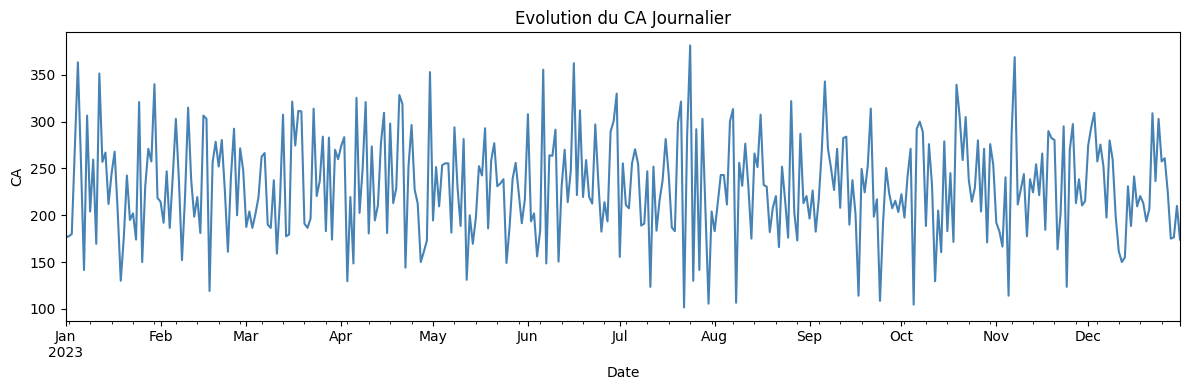

In [46]:
# Graphique 4 : CA journalier (courbe)
ca_journalier = df.groupby("Date")["Total_Depense"].sum()
ca_journalier.plot(kind="line", figsize=(12, 4), color="steelblue")
plt.title("Evolution du CA Journalier")
plt.xlabel("Date")
plt.ylabel("CA")
plt.tight_layout()
plt.show()

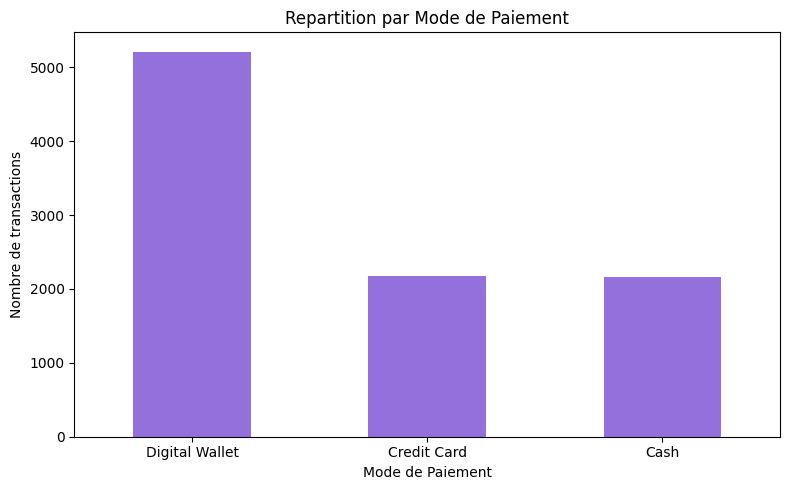

In [47]:
# Graphique 5 : Repartition par mode de paiement
df["Mode_Paiement"].value_counts().plot(kind="bar", color="mediumpurple", figsize=(8, 5))
plt.title("Repartition par Mode de Paiement")
plt.xlabel("Mode de Paiement")
plt.ylabel("Nombre de transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

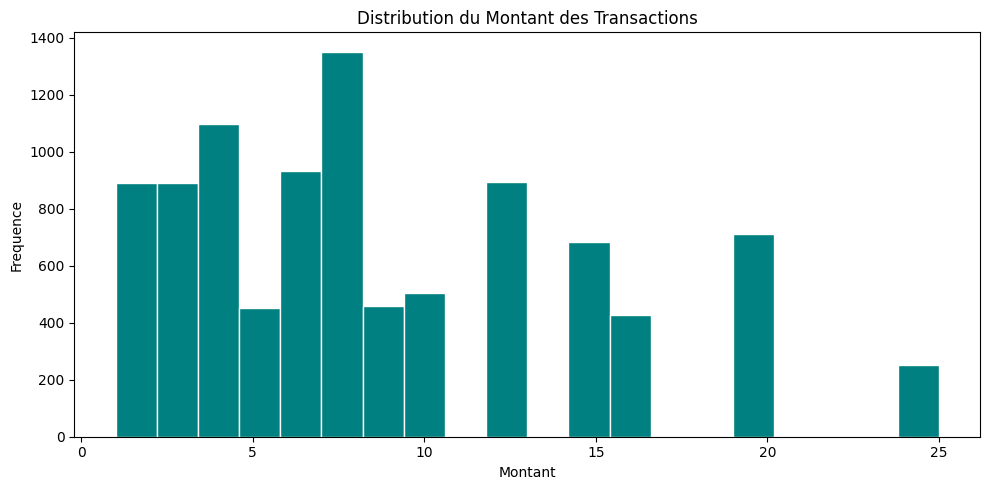

In [48]:
# Graphique 6 : Distribution du montant des transactions
df["Total_Depense"].plot(kind="hist", bins=20, color="teal", edgecolor="white", figsize=(10, 5))
plt.title("Distribution du Montant des Transactions")
plt.xlabel("Montant")
plt.ylabel("Frequence")
plt.tight_layout()
plt.show()

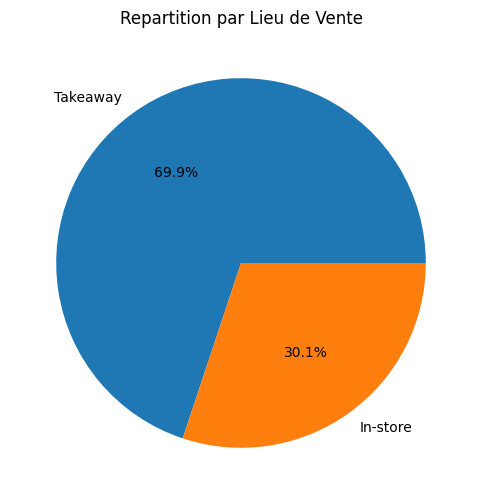

In [49]:
# Graphique 7 : Repartition par lieu
df["Lieu"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6, 6))
plt.title("Repartition par Lieu de Vente")
plt.ylabel("")
plt.show()

## Partie 14 : KPI - Indicateurs Clés de Performance

In [50]:
ca_total = df["Total_Depense"].sum()
print("CA total :", ca_total)

CA total : 84608.5


In [51]:
panier_moyen = df["Total_Depense"].mean()
print("Panier moyen :", round(panier_moyen, 2))

Panier moyen : 8.87


In [52]:
nb_transactions = len(df)
print("Nombre de transactions :", nb_transactions)

Nombre de transactions : 9540


In [53]:
produit_top = df["Produit"].value_counts().idxmax()
print("Produit le plus vendu :", produit_top)

Produit le plus vendu : Juice


In [54]:
mois_top = df.groupby("Mois")["Total_Depense"].sum().idxmax()
print("Meilleur mois :", mois_top)

Meilleur mois : 10


In [55]:
paiement_top = df["Mode_Paiement"].value_counts().idxmax()
print("Mode de paiement dominant :", paiement_top)

Mode de paiement dominant : Digital Wallet


In [56]:
lieu_top = df["Lieu"].value_counts().idxmax()
print("Lieu dominant :", lieu_top)

Lieu dominant : Takeaway


## Partie 15 : Sauvegarde des données nettoyées

In [57]:
df.to_csv("cafe_sales_clean.csv", index=False)
print("Fichier sauvegarde")
print(df.shape)
print(df.columns)

Fichier sauvegarde
(9540, 14)
Index(['ID_Transaction', 'Produit', 'Quantite', 'Prix_Unitaire',
       'Total_Depense', 'Mode_Paiement', 'Lieu', 'Date', 'Annee', 'Mois',
       'Jour', 'Jour_Semaine', 'Nom_Jour', 'CA'],
      dtype='str')
